In [79]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from scipy import stats

In [80]:
df = pd.read_csv(r"Data_sets\titanic.csv" , usecols=["age" , "fare" , "survived"])


In [81]:
print(df)

     survived   age     fare
0           0  22.0   7.2500
1           1  38.0  71.2833
2           1  26.0   7.9250
3           1  35.0  53.1000
4           0  35.0   8.0500
..        ...   ...      ...
886         0  27.0  13.0000
887         1  19.0  30.0000
888         0   NaN  23.4500
889         1  26.0  30.0000
890         0  32.0   7.7500

[891 rows x 3 columns]


In [82]:
df["age"] =df["age"].fillna(df["age"].mean(), inplace=True)

C:\Users\jzaid\AppData\Local\Temp\ipykernel_20128\3196420552.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["age"] =df["age"].fillna(df["age"].mean(), inplace=True)


In [83]:
df.isnull().sum()

survived    0
age         0
fare        0
dtype: int64

In [84]:
X = df.iloc[:,1:3]
y = df.iloc[: ,0]

In [85]:
X_Train , X_Test , y_Train , y_Test = train_test_split(X,y ,test_size=0.2 , random_state=42)

C:\Users\jzaid\AppData\Local\Temp\ipykernel_20128\321981307.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_Train["age"])


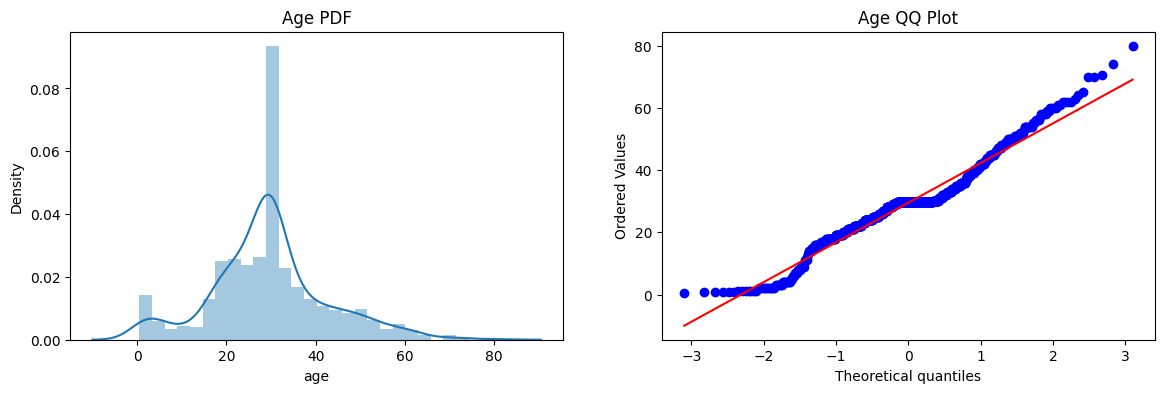

In [86]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_Train["age"])
plt.title("Age PDF")


plt.subplot(122)
stats.probplot(X_Train["age"] , dist = "norm" , plot = plt)
plt.title("Age QQ Plot")

plt.show()

<Figure size 2000x400 with 0 Axes>

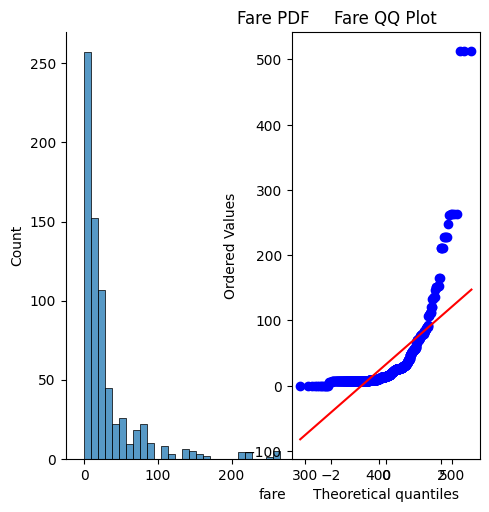

In [87]:
plt.figure(figsize= (20,4))
# plt.subplot(121)
sns.displot(X_Train["fare"])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_Train['fare'] , dist="norm" , plot=plt)
plt.title("Fare QQ Plot")
plt.show()

In [88]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [89]:
# X_Train["age"] = X_Train["age"].fillna(X_Train["age"].mean())
# X_Test["age"] = X_Test["age"].fillna(X_Test["age"].mean())

In [92]:
# X_Train.isnull().sum()

In [93]:
clf.fit(X_Train, y_Train)
clf2.fit(X_Train , y_Train)

y_predict = clf.predict(X_Test )
y_predict1 = clf2.predict(X_Test)

print("accuracy_score" , accuracy_score (y_Test , y_predict))
print("accuracy_score" , accuracy_score(y_Test , y_predict1))


accuracy_score 0.6480446927374302
accuracy_score 0.659217877094972


In [94]:
trf =FunctionTransformer(func=np.log1p)

In [95]:
X_Train_Transform = trf.fit_transform(X_Train)
X_Test_Transform = trf.transform(X_Test)

In [96]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [ ]:
clf.fit(X_Train_Transform , y_Train)
clf2.fit(X_Train_Transform,X_Train )

y_pred = clf.predict(X_Test)
y_pred1 = clf2.predict(X_Test)


print("Accuracy LR " , accuracy_score(y_Test , y_pred))
print("Accuracy DT " , accuracy_score(y_Test , y_pred1))